In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

from google.colab import drive

mount_point = Path("/content/gdrive_results")

counter = 1
while mount_point.exists() and any(mount_point.iterdir()):
    counter += 1
    mount_point = Path(f"/content/gdrive_results_{counter}")

print("Using mount point:", mount_point)

drive.mount(str(mount_point), force_remount=True)

MYDRIVE = mount_point / "MyDrive"

project_matches = list(MYDRIVE.rglob("Project596_datafiles"))

print("\nProject folder matches")
print("=" * 70)

for match in project_matches:
    print(match)

if len(project_matches) == 0:
    raise FileNotFoundError("Could not find Project596_datafiles under MyDrive.")

DATA_RAW = project_matches[0]
DATA_PROCESSED = DATA_RAW / "processed_data"
FIGURES = DATA_RAW / "figures"
TABLES = DATA_RAW / "tables"

for folder in [FIGURES, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

daily_path = DATA_PROCESSED / "daily_environmental_analysis_ready.csv"

print("\nDaily file path")
print("=" * 70)
print(daily_path)
print("File exists:", daily_path.exists())

if not daily_path.exists():
    print("\nFiles inside processed_data:")
    for file in sorted(DATA_PROCESSED.iterdir()):
        print(file.name)
    raise FileNotFoundError("daily_environmental_analysis_ready.csv was not found in processed_data.")

daily = pd.read_csv(daily_path)
daily["date"] = pd.to_datetime(daily["date"], errors="coerce")

print("\nLoaded daily environmental analysis-ready file")
print("=" * 70)
print("Rows:", len(daily))
print("Columns:", daily.shape[1])
print("Date range:", daily["date"].min(), "to", daily["date"].max())
print("Unique dates:", daily["date"].nunique())
print("Duplicate dates:", daily["date"].duplicated().sum())

key_fields = [
    "date",
    "active_advisory_records",
    "active_closure_records",
    "active_posting_records",
    "active_sewage_related_records",
    "active_tijuana_river_related_records",
    "rain_mm",
    "rain_lag1_mm",
    "rain_3day_mm",
    "rain_7day_mm",
    "rainy_day",
    "discharge_m3s",
    "discharge_cfs",
    "discharge_mgd",
    "high_flow_day",
    "flow_category",
    "high_flow_1day_window",
    "high_flow_3day_window",
    "high_flow_7day_window",
]

existing_key_fields = [col for col in key_fields if col in daily.columns]
missing_key_fields = [col for col in key_fields if col not in daily.columns]

print("\nMissing expected key fields:")
print(missing_key_fields)

print("\nMissing values in existing key fields:")
print(daily[existing_key_fields].isna().sum())

print("\nAvailable active record-day columns:")
active_cols = [col for col in daily.columns if col.startswith("active_")]
print(active_cols)

print("\nFirst 5 rows:")
display(daily[existing_key_fields].head())

Using mount point: /content/gdrive_results
Mounted at /content/gdrive_results

Project folder matches
/content/gdrive_results/MyDrive/STAT596/Project596_datafiles

Daily file path
/content/gdrive_results/MyDrive/STAT596/Project596_datafiles/processed_data/daily_environmental_analysis_ready.csv
File exists: True

Loaded daily environmental analysis-ready file
Rows: 1159
Columns: 77
Date range: 2023-01-01 00:00:00 to 2026-03-04 00:00:00
Unique dates: 1159
Duplicate dates: 0

Missing expected key fields:
[]

Missing values in existing key fields:
date                                    0
active_advisory_records                 0
active_closure_records                  0
active_posting_records                  0
active_sewage_related_records           0
active_tijuana_river_related_records    0
rain_mm                                 0
rain_lag1_mm                            1
rain_3day_mm                            0
rain_7day_mm                            0
rainy_day                     

,date,active_advisory_records,active_closure_records,active_posting_records,active_sewage_related_records,active_tijuana_river_related_records,rain_mm,rain_lag1_mm,rain_3day_mm,rain_7day_mm,rainy_day,discharge_m3s,discharge_cfs,discharge_mgd,high_flow_day,flow_category,high_flow_1day_window,high_flow_3day_window,high_flow_7day_window
0,2023-01-01,6,3,2,3,3,27.576860,NaN,27.576860,27.576860,True,78.30,2765.141010,1787.158350,1,Extreme flow,1,1,1
1,2023-01-02,7,4,2,4,4,1.540973,27.576860,29.117833,29.117833,False,9.46,334.077062,215.919770,1,Very high flow,1,1,1
2,2023-01-03,6,4,1,4,4,2.886682,1.540973,32.004515,32.004515,True,5.09,179.751823,116.176705,1,High flow,1,1,1
3,2023-01-04,6,4,1,4,4,3.600200,2.886682,8.027854,35.604715,True,3.52,124.307744,80.342240,1,High flow,1,1,1
4,2023-01-05,6,4,1,4,4,0.755641,3.600200,7.242523,36.360356,False,3.76,132.783272,85.820120,1,High flow,1,1,1


In [3]:
# Documents the study period, daily unit of analysis,
# and key result fields for the paper

import pandas as pd
from IPython.display import display

TABLES.mkdir(parents=True, exist_ok=True)

daily = daily.copy()
daily["date"] = pd.to_datetime(daily["date"], errors="coerce")

active_record_columns = [
    col for col in daily.columns
    if col.startswith("active_") and col.endswith("_records")
]

main_daily_fields = [
    "active_advisory_records",
    "active_closure_records",
    "active_posting_records",
    "active_sewage_related_records",
    "active_tijuana_river_related_records",
    "rain_mm",
    "rain_lag1_mm",
    "rain_3day_mm",
    "rain_7day_mm",
    "rainy_day",
    "discharge_m3s",
    "discharge_cfs",
    "discharge_mgd",
    "high_flow_day",
    "high_flow_1day_window",
    "high_flow_3day_window",
    "high_flow_7day_window"
]

summary_rows = [
    {"summary_item": "dataset_name", "summary_value": "daily_environmental_analysis_ready.csv"},
    {"summary_item": "notebook", "summary_value": "10_daily_environmental_results.ipynb"},
    {"summary_item": "unit_of_analysis", "summary_value": "one row per calendar day"},
    {"summary_item": "result_language", "summary_value": "active record-days"},
    {"summary_item": "analysis_type", "summary_value": "exploratory daily environmental results"},
    {"summary_item": "start_date", "summary_value": daily["date"].min().strftime("%Y-%m-%d")},
    {"summary_item": "end_date", "summary_value": daily["date"].max().strftime("%Y-%m-%d")},
    {"summary_item": "total_days", "summary_value": daily["date"].nunique()},
    {"summary_item": "total_rows", "summary_value": len(daily)},
    {"summary_item": "total_columns", "summary_value": daily.shape[1]},
    {"summary_item": "duplicate_dates", "summary_value": daily["date"].duplicated().sum()},
    {"summary_item": "missing_dates", "summary_value": daily["date"].isna().sum()},
    {"summary_item": "active_record_day_columns", "summary_value": len(active_record_columns)},
    {"summary_item": "main_daily_fields_present", "summary_value": sum(col in daily.columns for col in main_daily_fields)},
    {"summary_item": "main_daily_fields_expected", "summary_value": len(main_daily_fields)},
    {"summary_item": "active_record_day_column_names", "summary_value": ", ".join(active_record_columns)}
]

dataset_summary = pd.DataFrame(summary_rows)

summary_path = TABLES / "daily_environmental_dataset_summary.csv"
dataset_summary.to_csv(summary_path, index=False)

reloaded_summary = pd.read_csv(summary_path)

print("Saved dataset summary table")
print("=" * 70)
print(f"Path: {summary_path}")
print(f"File exists: {summary_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_summary)}")
print(f"Columns: {reloaded_summary.shape[1]}")
print(f"Missing summary items: {reloaded_summary['summary_item'].isna().sum()}")
print(f"Missing summary values: {reloaded_summary['summary_value'].isna().sum()}")

display(reloaded_summary)

Saved dataset summary table
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/daily_environmental_dataset_summary.csv
File exists: True

Reloaded QA
Rows: 16
Columns: 2
Missing summary items: 0
Missing summary values: 0


,summary_item,summary_value
0,dataset_name,daily_environmental_analysis_ready.csv
1,notebook,10_daily_environmental_results.ipynb
2,unit_of_analysis,one row per calendar day
3,result_language,active record-days
4,analysis_type,exploratory daily environmental results
5,start_date,2023-01-01
6,end_date,2026-03-04
7,total_days,1159
8,total_rows,1159
9,total_columns,77


In [4]:
# result table for beach active record-days

import numpy as np
import pandas as pd
from IPython.display import display

record_day_columns = [
    "active_advisory_records",
    "active_closure_records",
    "active_posting_records",
    "active_sewage_related_records",
    "active_tijuana_river_related_records"
]

record_day_labels = {
    "active_advisory_records": "Active advisory record-days",
    "active_closure_records": "Active closure record-days",
    "active_posting_records": "Active posting record-days",
    "active_sewage_related_records": "Active sewage-related record-days",
    "active_tijuana_river_related_records": "Active Tijuana River-related record-days"
}

summary_rows = []

for col in record_day_columns:
    values = pd.to_numeric(daily[col], errors="coerce")
    active_days = (values > 0).sum()

    summary_rows.append({
        "measure": record_day_labels[col],
        "column_name": col,
        "total_active_record_days": values.sum(),
        "mean_active_record_days_per_day": values.mean(),
        "median_active_record_days_per_day": values.median(),
        "std_active_record_days_per_day": values.std(),
        "min_active_record_days_per_day": values.min(),
        "max_active_record_days_per_day": values.max(),
        "days_with_at_least_one_active_record": active_days,
        "percent_days_with_at_least_one_active_record": (active_days / len(daily)) * 100
    })

daily_record_day_summary = pd.DataFrame(summary_rows)

round_cols = [
    "mean_active_record_days_per_day",
    "median_active_record_days_per_day",
    "std_active_record_days_per_day",
    "percent_days_with_at_least_one_active_record"
]

daily_record_day_summary[round_cols] = daily_record_day_summary[round_cols].round(2)

summary_path = TABLES / "daily_active_record_day_summary.csv"
daily_record_day_summary.to_csv(summary_path, index=False)

reloaded_summary = pd.read_csv(summary_path)

print("Saved daily active record-day summary table")
print("=" * 70)
print(f"Path: {summary_path}")
print(f"File exists: {summary_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_summary)}")
print(f"Columns: {reloaded_summary.shape[1]}")
print(f"Missing values: {reloaded_summary.isna().sum().sum()}")

display(reloaded_summary)

Saved daily active record-day summary table
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/daily_active_record_day_summary.csv
File exists: True

Reloaded QA
Rows: 5
Columns: 10
Missing values: 0


,measure,column_name,total_active_record_days,mean_active_record_days_per_day,median_active_record_days_per_day,std_active_record_days_per_day,min_active_record_days_per_day,max_active_record_days_per_day,days_with_at_least_one_active_record,percent_days_with_at_least_one_active_record
0,Active advisory record-days,active_advisory_records,12915,11.14,11.0,3.66,2,23,1159,100.00
1,Active closure record-days,active_closure_records,6005,5.18,5.0,2.38,1,15,1159,100.00
2,Active posting record-days,active_posting_records,6711,5.79,5.0,3.64,0,20,1127,97.24
3,Active sewage-related record-days,active_sewage_related_records,6034,5.21,5.0,2.37,1,15,1159,100.00
4,Active Tijuana River-related record-days,active_tijuana_river_related_records,5768,4.98,5.0,2.10,1,9,1159,100.00


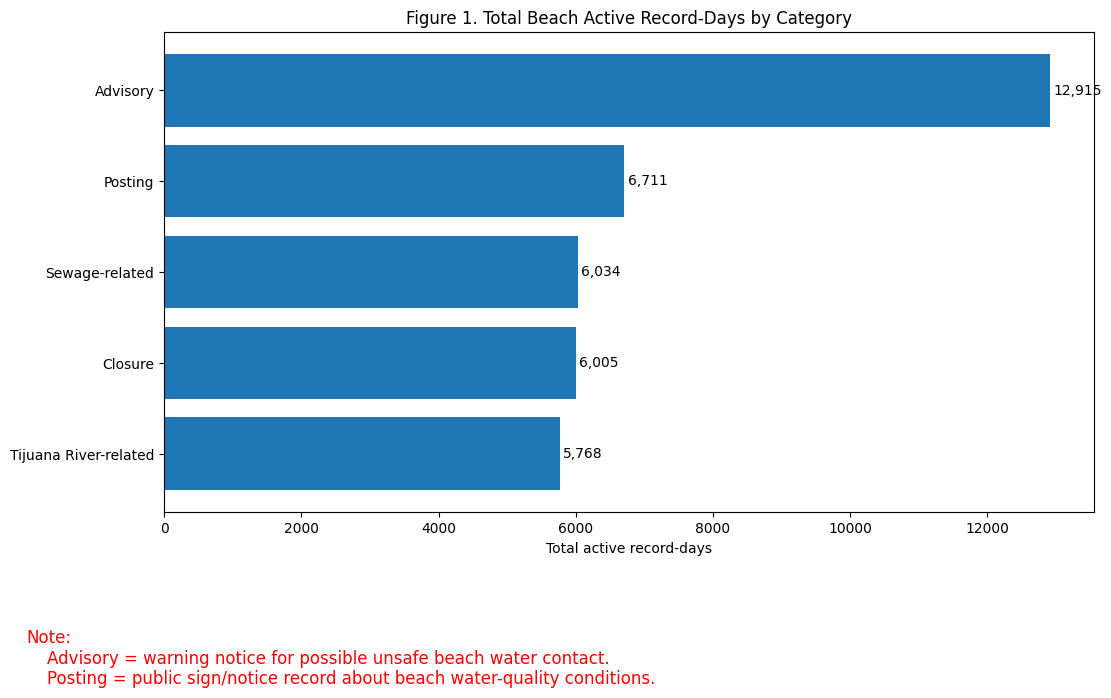

Saved Figure 1
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/figures/figure_1_total_beach_active_record_days_by_category.png
File exists: True


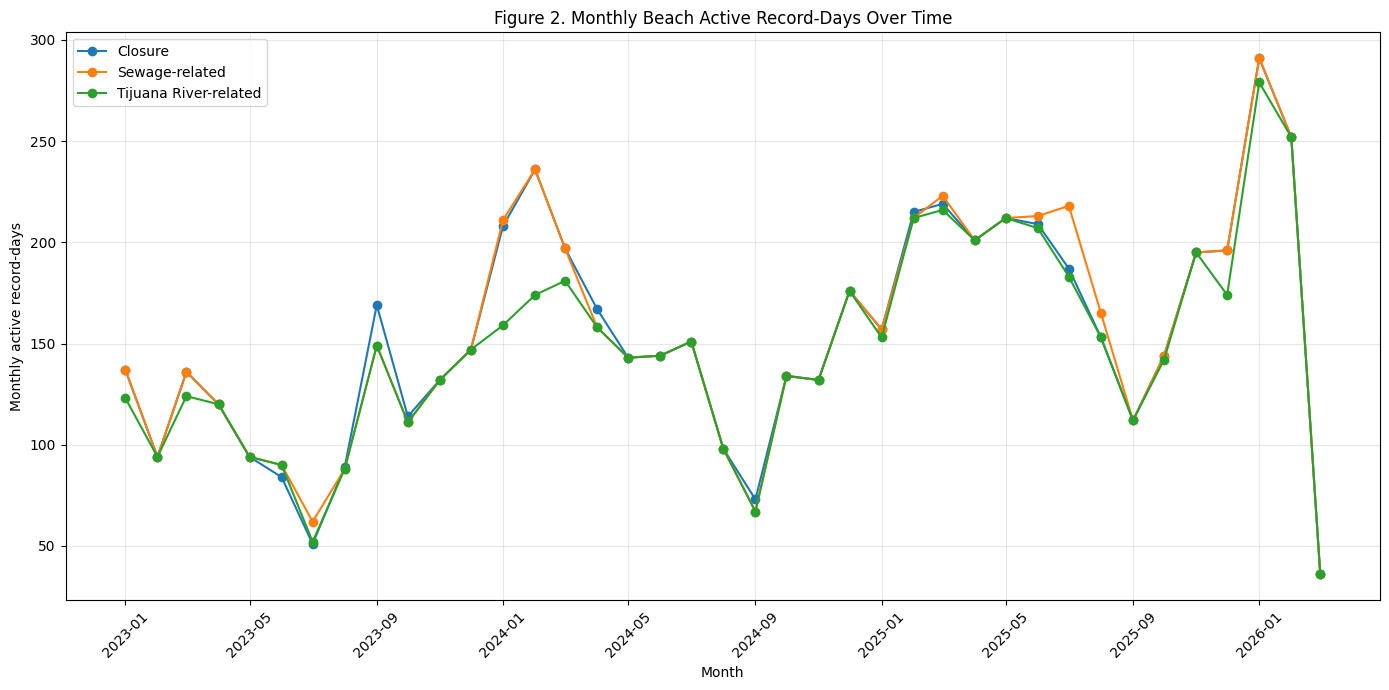

Saved Figure 2
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/figures/figure_2_monthly_beach_active_record_days_over_time.png
File exists: True


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

note_text = (
    "Note:\n"
    "    Advisory = warning notice for possible unsafe beach water contact.\n"
    "    Posting = public sign/notice record about beach water-quality conditions."
)

figure1_order = [
    ("Advisory", "active_advisory_records"),
    ("Posting", "active_posting_records"),
    ("Sewage-related", "active_sewage_related_records"),
    ("Closure", "active_closure_records"),
    ("Tijuana River-related", "active_tijuana_river_related_records")
]

fig1_labels = [item[0] for item in figure1_order]

fig1_values = [
    daily_record_day_summary.loc[
        daily_record_day_summary["column_name"] == col,
        "total_active_record_days"
    ].iloc[0]
    for label, col in figure1_order
]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(fig1_labels, fig1_values)

ax.invert_yaxis()
ax.set_title("Figure 1. Total Beach Active Record-Days by Category")
ax.set_xlabel("Total active record-days")

for bar, value in zip(bars, fig1_values):
    ax.text(
        value + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center"
    )

plt.subplots_adjust(bottom=0.28)

fig.text(
    0.01,
    0.06,
    note_text,
    ha="left",
    va="bottom",
    color="red",
    fontsize=12
)

figure1_path = FIGURES / "figure_1_total_beach_active_record_days_by_category.png"
fig.savefig(figure1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 1")
print(f"Path: {figure1_path}")
print(f"File exists: {figure1_path.exists()}")


plot_df = monthly_environmental_summary.copy()
plot_df["year_month"] = pd.to_datetime(plot_df["year_month"])

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    plot_df["year_month"],
    plot_df["active_closure_record_days"],
    marker="o",
    label="Closure"
)

ax.plot(
    plot_df["year_month"],
    plot_df["active_sewage_related_record_days"],
    marker="o",
    label="Sewage-related"
)

ax.plot(
    plot_df["year_month"],
    plot_df["active_tijuana_river_related_record_days"],
    marker="o",
    label="Tijuana River-related"
)

ax.set_title("Figure 2. Monthly Beach Active Record-Days Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly active record-days")
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

figure2_path = FIGURES / "figure_2_monthly_beach_active_record_days_over_time.png"
fig.savefig(figure2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 2")
print(f"Path: {figure2_path}")
print(f"File exists: {figure2_path.exists()}")

Figure 1 shows that advisories happened the most during the study period, with 12,915 active advisory record-days. Posting was the second most recorded activity, but the interesting part is the sewage-related reports and closures. One can infer that those two categories were connected, even though they are not exactly the same.

The Tijuana River-related category is lower than those two, which can suggest that not every closure or sewage-related record was labeled as Tijuana River-related. Still, the totals are close enough to show that the Tijuana River was a major part of the beach activity pattern.

Figure 2 uses the same type of data but adds time to show a clearer pattern. It shows that closure, sewage-related, and Tijuana River-related record-days followed a similar pattern over time. When closures increased, sewage-related and Tijuana River-related record-days usually increased too. The highest monthly values appear around early 2026, especially January and February. It is fair to note that March 2026 only includes a small number of days, so the drop in March should not be treated as a full monthly comparison at this stage of the analysis.

In [5]:
import pandas as pd
from IPython.display import display

daily = daily.copy()
daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
daily["year_month"] = daily["date"].dt.to_period("M").astype(str)

monthly_environmental_summary = (
    daily
    .groupby("year_month", as_index=False)
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        days_in_month=("date", "nunique"),
        active_advisory_record_days=("active_advisory_records", "sum"),
        active_closure_record_days=("active_closure_records", "sum"),
        active_posting_record_days=("active_posting_records", "sum"),
        active_sewage_related_record_days=("active_sewage_related_records", "sum"),
        active_tijuana_river_related_record_days=("active_tijuana_river_related_records", "sum"),
        total_rain_mm=("rain_mm", "sum"),
        rainy_days=("rainy_day", "sum"),
        mean_discharge_m3s=("discharge_m3s", "mean"),
        max_discharge_m3s=("discharge_m3s", "max"),
        high_flow_days=("high_flow_day", "sum")
    )
)

round_cols = [
    "total_rain_mm",
    "mean_discharge_m3s",
    "max_discharge_m3s"
]

monthly_environmental_summary[round_cols] = monthly_environmental_summary[round_cols].round(2)

summary_path = TABLES / "monthly_environmental_results_summary.csv"
monthly_environmental_summary.to_csv(summary_path, index=False)

reloaded_summary = pd.read_csv(summary_path)

print("Saved monthly environmental results summary table")
print("=" * 70)
print(f"Path: {summary_path}")
print(f"File exists: {summary_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_summary)}")
print(f"Columns: {reloaded_summary.shape[1]}")
print(f"Missing values: {reloaded_summary.isna().sum().sum()}")
print(f"First month: {reloaded_summary['year_month'].min()}")
print(f"Last month: {reloaded_summary['year_month'].max()}")

display(reloaded_summary.head())
display(reloaded_summary.tail())

Saved monthly environmental results summary table
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/monthly_environmental_results_summary.csv
File exists: True

Reloaded QA
Rows: 39
Columns: 14
Missing values: 0
First month: 2023-01
Last month: 2026-03


,year_month,start_date,end_date,days_in_month,active_advisory_record_days,active_closure_record_days,active_posting_record_days,active_sewage_related_record_days,active_tijuana_river_related_record_days,total_rain_mm,rainy_days,mean_discharge_m3s,max_discharge_m3s,high_flow_days
0,2023-01,2023-01-01,2023-01-31,31,224,137,65,137,123,147.10,10,20.42,253.00,24
1,2023-02,2023-02-01,2023-02-28,28,212,94,106,94,94,56.72,5,5.65,58.00,10
2,2023-03,2023-03-01,2023-03-31,31,255,136,97,136,124,126.66,11,18.13,83.40,31
3,2023-04,2023-04-01,2023-04-30,30,287,120,165,120,120,2.54,0,3.74,9.19,22
4,2023-05,2023-05-01,2023-05-31,31,311,94,217,94,94,3.42,0,1.47,2.95,1


,year_month,start_date,end_date,days_in_month,active_advisory_record_days,active_closure_record_days,active_posting_record_days,active_sewage_related_record_days,active_tijuana_river_related_record_days,total_rain_mm,rainy_days,mean_discharge_m3s,max_discharge_m3s,high_flow_days
34,2025-11,2025-11-01,2025-11-30,30,283,195,78,195,195,61.54,4,4.28,40.60,6
35,2025-12,2025-12-01,2025-12-31,31,309,196,106,196,174,24.56,2,3.33,26.30,4
36,2026-01,2026-01-01,2026-01-31,31,356,291,57,291,279,75.12,4,7.65,159.00,5
37,2026-02,2026-02-01,2026-02-28,28,422,252,158,252,252,49.04,5,7.97,55.60,6
38,2026-03,2026-03-01,2026-03-04,4,57,36,21,36,36,0.00,0,1.80,1.85,0


In [7]:
# Tests whether beach active record-days were higher on rainy days than dry days.
import numpy as np
import pandas as pd
from IPython.display import display

comparison_columns = [
    "active_advisory_records",
    "active_closure_records",
    "active_posting_records",
    "active_sewage_related_records",
    "active_tijuana_river_related_records"
]

comparison_labels = {
    "active_advisory_records": "Active advisory record-days",
    "active_closure_records": "Active closure record-days",
    "active_posting_records": "Active posting record-days",
    "active_sewage_related_records": "Active sewage-related record-days",
    "active_tijuana_river_related_records": "Active Tijuana River-related record-days"
}

daily = daily.copy()
daily["rainy_day"] = daily["rainy_day"].astype(bool)

summary_rows = []

for col in comparison_columns:
    rainy_values = pd.to_numeric(daily.loc[daily["rainy_day"], col], errors="coerce")
    dry_values = pd.to_numeric(daily.loc[~daily["rainy_day"], col], errors="coerce")

    rainy_mean = rainy_values.mean()
    dry_mean = dry_values.mean()

    if dry_mean == 0:
        percent_increase = np.nan
    else:
        percent_increase = ((rainy_mean - dry_mean) / dry_mean) * 100

    summary_rows.append({
        "measure": comparison_labels[col],
        "column_name": col,
        "rainy_days": rainy_values.count(),
        "dry_days": dry_values.count(),
        "rainy_total_active_record_days": rainy_values.sum(),
        "dry_total_active_record_days": dry_values.sum(),
        "rainy_mean_active_record_days": rainy_mean,
        "dry_mean_active_record_days": dry_mean,
        "rainy_median_active_record_days": rainy_values.median(),
        "dry_median_active_record_days": dry_values.median(),
        "mean_difference_rainy_minus_dry": rainy_mean - dry_mean,
        "percent_increase_on_rainy_days": percent_increase
    })

rainy_dry_comparison = pd.DataFrame(summary_rows)

round_cols = [
    "rainy_mean_active_record_days",
    "dry_mean_active_record_days",
    "rainy_median_active_record_days",
    "dry_median_active_record_days",
    "mean_difference_rainy_minus_dry",
    "percent_increase_on_rainy_days"
]

rainy_dry_comparison[round_cols] = rainy_dry_comparison[round_cols].round(2)

comparison_path = TABLES / "rainy_vs_dry_active_record_day_comparison.csv"
rainy_dry_comparison.to_csv(comparison_path, index=False)

reloaded_comparison = pd.read_csv(comparison_path)

print("Saved rainy vs dry active record-day comparison table")
print("=" * 70)
print(f"Path: {comparison_path}")
print(f"File exists: {comparison_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_comparison)}")
print(f"Columns: {reloaded_comparison.shape[1]}")
print(f"Missing values: {reloaded_comparison.isna().sum().sum()}")
print(f"Rainy days in dataset: {daily['rainy_day'].sum()}")
print(f"Dry days in dataset: {(~daily['rainy_day']).sum()}")

display(reloaded_comparison)


Saved rainy vs dry active record-day comparison table
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/rainy_vs_dry_active_record_day_comparison.csv
File exists: True

Reloaded QA
Rows: 5
Columns: 12
Missing values: 0
Rainy days in dataset: 80
Dry days in dataset: 1079


,measure,column_name,rainy_days,dry_days,rainy_total_active_record_days,dry_total_active_record_days,rainy_mean_active_record_days,dry_mean_active_record_days,rainy_median_active_record_days,dry_median_active_record_days,mean_difference_rainy_minus_dry,percent_increase_on_rainy_days
0,Active advisory record-days,active_advisory_records,80,1079,879,12036,10.99,11.15,10.0,11.0,-0.17,-1.50
1,Active closure record-days,active_closure_records,80,1079,510,5495,6.38,5.09,6.0,5.0,1.28,25.18
2,Active posting record-days,active_posting_records,80,1079,294,6417,3.68,5.95,3.0,5.0,-2.27,-38.21
3,Active sewage-related record-days,active_sewage_related_records,80,1079,508,5526,6.35,5.12,6.0,5.0,1.23,23.99
4,Active Tijuana River-related record-days,active_tijuana_river_related_records,80,1079,455,5313,5.69,4.92,6.0,5.0,0.76,15.51


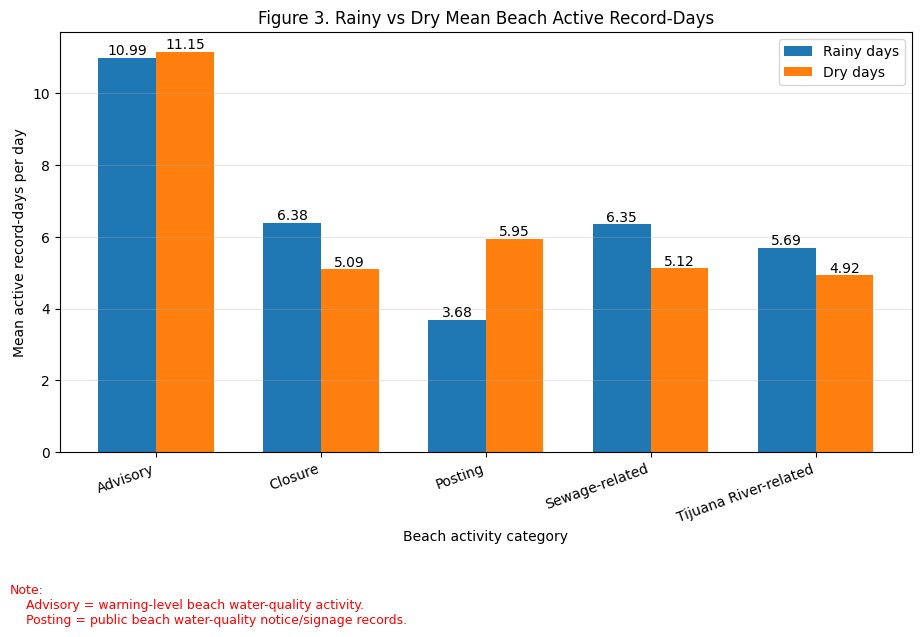

Saved figure
Figure 3 path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/figures/figure3_rainy_vs_dry_mean_active_record_days.png
Figure 3 exists: True


In [10]:
# visualization of rainy vs dry differences in beach active record-days.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIGURES.mkdir(parents=True, exist_ok=True)

figure3_data = rainy_dry_comparison.copy()

figure3_data["short_label"] = figure3_data["measure"].replace({
    "Active advisory record-days": "Advisory",
    "Active closure record-days": "Closure",
    "Active posting record-days": "Posting",
    "Active sewage-related record-days": "Sewage-related",
    "Active Tijuana River-related record-days": "Tijuana River-related"
})

x = np.arange(len(figure3_data))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 7))

bars1 = ax.bar(
    x - width / 2,
    figure3_data["rainy_mean_active_record_days"],
    width,
    label="Rainy days"
)

bars2 = ax.bar(
    x + width / 2,
    figure3_data["dry_mean_active_record_days"],
    width,
    label="Dry days"
)

ax.set_title("Figure 3. Rainy vs Dry Mean Beach Active Record-Days")
ax.set_xlabel("Beach activity category")
ax.set_ylabel("Mean active record-days per day")
ax.set_xticks(x)
ax.set_xticklabels(figure3_data["short_label"], rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom")

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom")

note_text = (
    "Note:\n"
    "    Advisory = warning-level beach water-quality activity.\n"
    "    Posting = public beach water-quality notice/signage records."
)

fig.subplots_adjust(bottom=0.28)

fig.text(
    0.08,
    0.03,
    note_text,
    ha="left",
    va="bottom",
    fontsize=9,
    color="red"
)

figure3_path = FIGURES / "figure3_rainy_vs_dry_mean_active_record_days.png"
fig.savefig(figure3_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure")
print("=" * 70)
print(f"Figure 3 path: {figure3_path}")
print(f"Figure 3 exists: {figure3_path.exists()}")

Figure 3 compares the average number of active record-days on rainy days and dry days. The main pattern is that rainy days had higher averages for closures, sewage-related records, and Tijuana River-related records. Closures increased from 5.09 on dry days to 6.38 on rainy days, and sewage-related records increased from 5.12 to 6.35. Tijuana River-related records also increased from 4.92 to 5.69.

This supports the idea that rainfall may be connected with higher beach-impact activity, especially for closure and sewage-related conditions. Advisory records were almost the same on rainy and dry days, while posting records were lower on rainy days. Overall, this graph suggests that rain is more connected to closure and sewage-related beach activity than to general advisories or postings.

In [15]:
#Tests whether beach active record-days were higher during Tijuana River high-flow windows.

comparison_columns = [
    "active_advisory_records",
    "active_closure_records",
    "active_posting_records",
    "active_sewage_related_records",
    "active_tijuana_river_related_records"
]

comparison_labels = {
    "active_advisory_records": "Active advisory record-days",
    "active_closure_records": "Active closure record-days",
    "active_posting_records": "Active posting record-days",
    "active_sewage_related_records": "Active sewage-related record-days",
    "active_tijuana_river_related_records": "Active Tijuana River-related record-days"
}

flow_windows = {
    "Same-day high-flow": "high_flow_day",
    "1-day high-flow window": "high_flow_1day_window",
    "3-day high-flow window": "high_flow_3day_window",
    "7-day high-flow window": "high_flow_7day_window"
}

summary_rows = []

for window_label, window_col in flow_windows.items():
    window_flag = pd.to_numeric(daily[window_col], errors="coerce").fillna(0).astype(int) == 1

    for col in comparison_columns:
        high_flow_values = pd.to_numeric(daily.loc[window_flag, col], errors="coerce")
        non_high_flow_values = pd.to_numeric(daily.loc[~window_flag, col], errors="coerce")

        high_flow_mean = high_flow_values.mean()
        non_high_flow_mean = non_high_flow_values.mean()

        if non_high_flow_mean == 0:
            percent_increase = np.nan
        else:
            percent_increase = ((high_flow_mean - non_high_flow_mean) / non_high_flow_mean) * 100

        summary_rows.append({
            "flow_window": window_label,
            "flow_window_column": window_col,
            "measure": comparison_labels[col],
            "column_name": col,
            "high_flow_window_days": high_flow_values.count(),
            "non_high_flow_window_days": non_high_flow_values.count(),
            "high_flow_window_total_active_record_days": high_flow_values.sum(),
            "non_high_flow_window_total_active_record_days": non_high_flow_values.sum(),
            "high_flow_window_mean_active_record_days": high_flow_mean,
            "non_high_flow_window_mean_active_record_days": non_high_flow_mean,
            "high_flow_window_median_active_record_days": high_flow_values.median(),
            "non_high_flow_window_median_active_record_days": non_high_flow_values.median(),
            "mean_difference_high_flow_minus_non_high_flow": high_flow_mean - non_high_flow_mean,
            "percent_increase_during_high_flow_window": percent_increase
        })

high_flow_window_comparison = pd.DataFrame(summary_rows)

round_cols = [
    "high_flow_window_mean_active_record_days",
    "non_high_flow_window_mean_active_record_days",
    "high_flow_window_median_active_record_days",
    "non_high_flow_window_median_active_record_days",
    "mean_difference_high_flow_minus_non_high_flow",
    "percent_increase_during_high_flow_window"
]

high_flow_window_comparison[round_cols] = high_flow_window_comparison[round_cols].round(2)

comparison_path = TABLES / "high_flow_window_active_record_day_comparison.csv"
high_flow_window_comparison.to_csv(comparison_path, index=False)

reloaded_comparison = pd.read_csv(comparison_path)

print("Saved high-flow window active record-day comparison table")
print("=" * 70)
print(f"Path: {comparison_path}")
print(f"File exists: {comparison_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_comparison)}")
print(f"Columns: {reloaded_comparison.shape[1]}")
print(f"Missing values: {reloaded_comparison.isna().sum().sum()}")

display(reloaded_comparison)

Saved high-flow window active record-day comparison table
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/high_flow_window_active_record_day_comparison.csv
File exists: True

Reloaded QA
Rows: 20
Columns: 14
Missing values: 0


,flow_window,flow_window_column,measure,column_name,high_flow_window_days,non_high_flow_window_days,high_flow_window_total_active_record_days,non_high_flow_window_total_active_record_days,high_flow_window_mean_active_record_days,non_high_flow_window_mean_active_record_days,high_flow_window_median_active_record_days,non_high_flow_window_median_active_record_days,mean_difference_high_flow_minus_non_high_flow,percent_increase_during_high_flow_window
0,Same-day high-flow,high_flow_day,Active advisory record-days,active_advisory_records,291,868,3471,9444,11.93,10.88,12.0,11.0,1.05,9.63
1,Same-day high-flow,high_flow_day,Active closure record-days,active_closure_records,291,868,1729,4276,5.94,4.93,6.0,5.0,1.02,20.61
2,Same-day high-flow,high_flow_day,Active posting record-days,active_posting_records,291,868,1588,5123,5.46,5.90,5.0,5.0,-0.45,-7.54
3,Same-day high-flow,high_flow_day,Active sewage-related record-days,active_sewage_related_records,291,868,1713,4321,5.89,4.98,6.0,5.0,0.91,18.25
4,Same-day high-flow,high_flow_day,Active Tijuana River-related record-days,active_tijuana_river_related_records,291,868,1546,4222,5.31,4.86,6.0,5.0,0.45,9.22
5,1-day high-flow window,high_flow_1day_window,Active advisory record-days,active_advisory_records,327,832,3878,9037,11.86,10.86,12.0,11.0,1.00,9.18
6,1-day high-flow window,high_flow_1day_window,Active closure record-days,active_closure_records,327,832,1936,4069,5.92,4.89,6.0,5.0,1.03,21.06
7,1-day high-flow window,high_flow_1day_window,Active posting record-days,active_posting_records,327,832,1770,4941,5.41,5.94,5.0,5.0,-0.53,-8.85
8,1-day high-flow window,high_flow_1day_window,Active sewage-related record-days,active_sewage_related_records,327,832,1918,4116,5.87,4.95,6.0,5.0,0.92,18.56
9,1-day high-flow window,high_flow_1day_window,Active Tijuana River-related record-days,active_tijuana_river_related_records,327,832,1747,4021,5.34,4.83,6.0,5.0,0.51,10.54


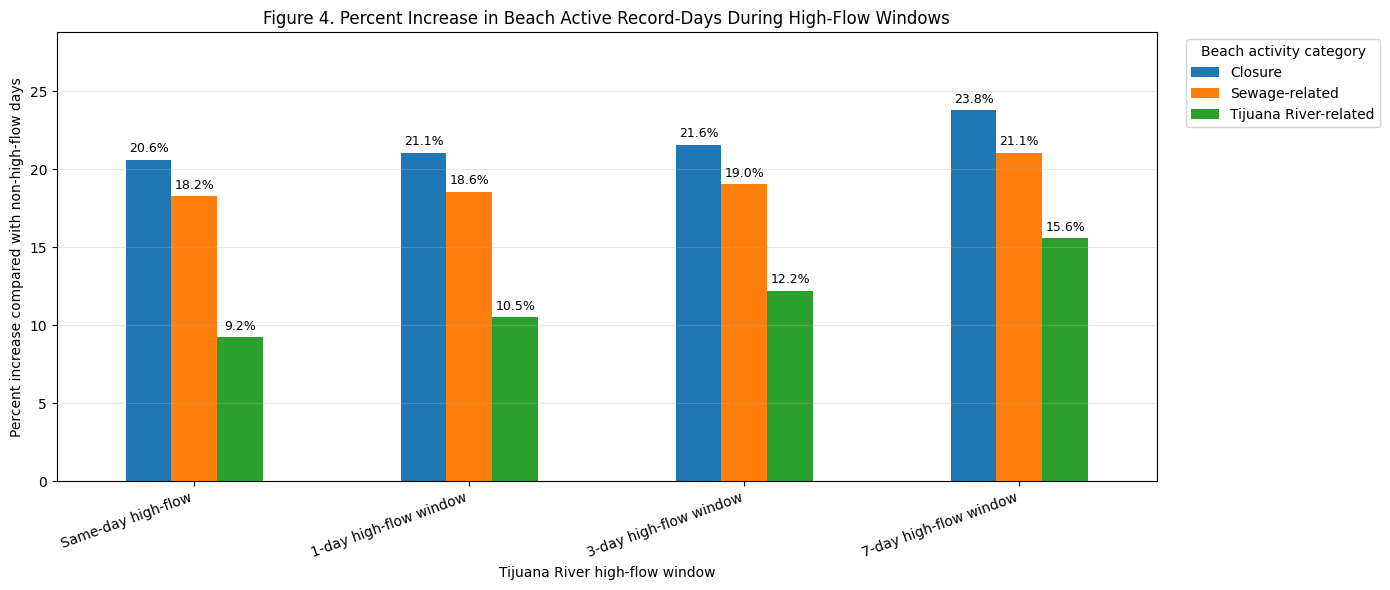

Saved Figure 4
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/figures/figure_4_high_flow_window_percent_increase.png


In [19]:
#show how beach impacts change during Tijuana River high-flow windows.
figure4_data = high_flow_window_comparison[
    high_flow_window_comparison["column_name"].isin([
        "active_closure_records",
        "active_sewage_related_records",
        "active_tijuana_river_related_records"
    ])
].copy()

figure4_data["short_measure"] = figure4_data["measure"].replace({
    "Active closure record-days": "Closure",
    "Active sewage-related record-days": "Sewage-related",
    "Active Tijuana River-related record-days": "Tijuana River-related"
})

window_order = [
    "Same-day high-flow",
    "1-day high-flow window",
    "3-day high-flow window",
    "7-day high-flow window"
]

pivot_fig4 = figure4_data.pivot(
    index="flow_window",
    columns="short_measure",
    values="percent_increase_during_high_flow_window"
).loc[window_order]

fig, ax = plt.subplots(figsize=(14, 6))

pivot_fig4.plot(kind="bar", ax=ax)

ax.set_title("Figure 4. Percent Increase in Beach Active Record-Days During High-Flow Windows")
ax.set_xlabel("Tijuana River high-flow window")
ax.set_ylabel("Percent increase compared with non-high-flow days")
ax.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

ax.legend(
    title="Beach activity category",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

ax.set_ylim(0, pivot_fig4.max().max() + 5)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

figure4_path = FIGURES / "figure_4_high_flow_window_percent_increase.png"
fig.savefig(figure4_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 4")
print(f"Path: {figure4_path}")

Before anything, let me explain why the data was separated into same-day, 1-day, 3-day, and 7-day windows. River flow may not affect beach activity only on the exact same day. High river flow can have a delayed effect because polluted water can move downstream, reach beaches later, or keep affecting water quality for several days. These windows help check whether beach active record-days are higher immediately or over a longer period after high flow.

We do have to be careful because the windows overlap. A 7-day window includes more days than the same-day window, so it is not a totally separate category. We used this comparison to help answer the question: “Do beach impacts stay higher as we widen the high-flow window?” Based on the data, closure, sewage-related, and Tijuana River-related active record-days stayed higher during all high-flow windows, with the largest percent increases appearing in the 7-day window.

In [20]:
#checking relationships between rainfall, river flow, and beach active record-days.

from scipy.stats import spearmanr

environmental_columns = [
    "rain_mm",
    "rain_lag1_mm",
    "rain_3day_mm",
    "rain_7day_mm",
    "discharge_m3s"
]

environmental_labels = {
    "rain_mm": "Same-day rainfall",
    "rain_lag1_mm": "1-day lag rainfall",
    "rain_3day_mm": "3-day rainfall total",
    "rain_7day_mm": "7-day rainfall total",
    "discharge_m3s": "Tijuana River discharge"
}

beach_columns = [
    "active_advisory_records",
    "active_closure_records",
    "active_posting_records",
    "active_sewage_related_records",
    "active_tijuana_river_related_records"
]

beach_labels = {
    "active_advisory_records": "Active advisory record-days",
    "active_closure_records": "Active closure record-days",
    "active_posting_records": "Active posting record-days",
    "active_sewage_related_records": "Active sewage-related record-days",
    "active_tijuana_river_related_records": "Active Tijuana River-related record-days"
}

correlation_rows = []

for env_col in environmental_columns:
    for beach_col in beach_columns:
        temp = daily[[env_col, beach_col]].copy()
        temp[env_col] = pd.to_numeric(temp[env_col], errors="coerce")
        temp[beach_col] = pd.to_numeric(temp[beach_col], errors="coerce")
        temp = temp.dropna()

        rho, p_value = spearmanr(temp[env_col], temp[beach_col])

        if abs(rho) < 0.10:
            strength = "very weak"
        elif abs(rho) < 0.30:
            strength = "weak"
        elif abs(rho) < 0.50:
            strength = "moderate"
        else:
            strength = "strong"

        if rho > 0:
            direction = "positive"
        elif rho < 0:
            direction = "negative"
        else:
            direction = "no direction"

        correlation_rows.append({
            "environmental_variable": environmental_labels[env_col],
            "environmental_column": env_col,
            "beach_measure": beach_labels[beach_col],
            "beach_column": beach_col,
            "n_observations": len(temp),
            "spearman_rho": rho,
            "p_value": p_value,
            "direction": direction,
            "strength": strength
        })

spearman_results = pd.DataFrame(correlation_rows)

spearman_results["spearman_rho"] = spearman_results["spearman_rho"].round(3)
spearman_results["p_value"] = spearman_results["p_value"].round(5)

spearman_path = TABLES / "daily_environmental_spearman_correlations.csv"
spearman_results.to_csv(spearman_path, index=False)

reloaded_spearman = pd.read_csv(spearman_path)

print("Saved Spearman correlation results table")
print("=" * 70)
print(f"Path: {spearman_path}")
print(f"File exists: {spearman_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_spearman)}")
print(f"Columns: {reloaded_spearman.shape[1]}")
print(f"Missing values: {reloaded_spearman.isna().sum().sum()}")

display(reloaded_spearman)


Saved Spearman correlation results table
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/daily_environmental_spearman_correlations.csv
File exists: True

Reloaded QA
Rows: 25
Columns: 9
Missing values: 0


,environmental_variable,environmental_column,beach_measure,beach_column,n_observations,spearman_rho,p_value,direction,strength
0,Same-day rainfall,rain_mm,Active advisory record-days,active_advisory_records,1159,0.045,0.12172,positive,very weak
1,Same-day rainfall,rain_mm,Active closure record-days,active_closure_records,1159,0.156,0.00000,positive,weak
2,Same-day rainfall,rain_mm,Active posting record-days,active_posting_records,1159,-0.120,0.00004,negative,weak
3,Same-day rainfall,rain_mm,Active sewage-related record-days,active_sewage_related_records,1159,0.146,0.00000,positive,weak
4,Same-day rainfall,rain_mm,Active Tijuana River-related record-days,active_tijuana_river_related_records,1159,0.128,0.00001,positive,weak
5,1-day lag rainfall,rain_lag1_mm,Active advisory record-days,active_advisory_records,1158,0.053,0.07226,positive,very weak
6,1-day lag rainfall,rain_lag1_mm,Active closure record-days,active_closure_records,1158,0.164,0.00000,positive,weak
7,1-day lag rainfall,rain_lag1_mm,Active posting record-days,active_posting_records,1158,-0.128,0.00001,negative,weak
8,1-day lag rainfall,rain_lag1_mm,Active sewage-related record-days,active_sewage_related_records,1158,0.152,0.00000,positive,weak
9,1-day lag rainfall,rain_lag1_mm,Active Tijuana River-related record-days,active_tijuana_river_related_records,1158,0.129,0.00001,positive,weak


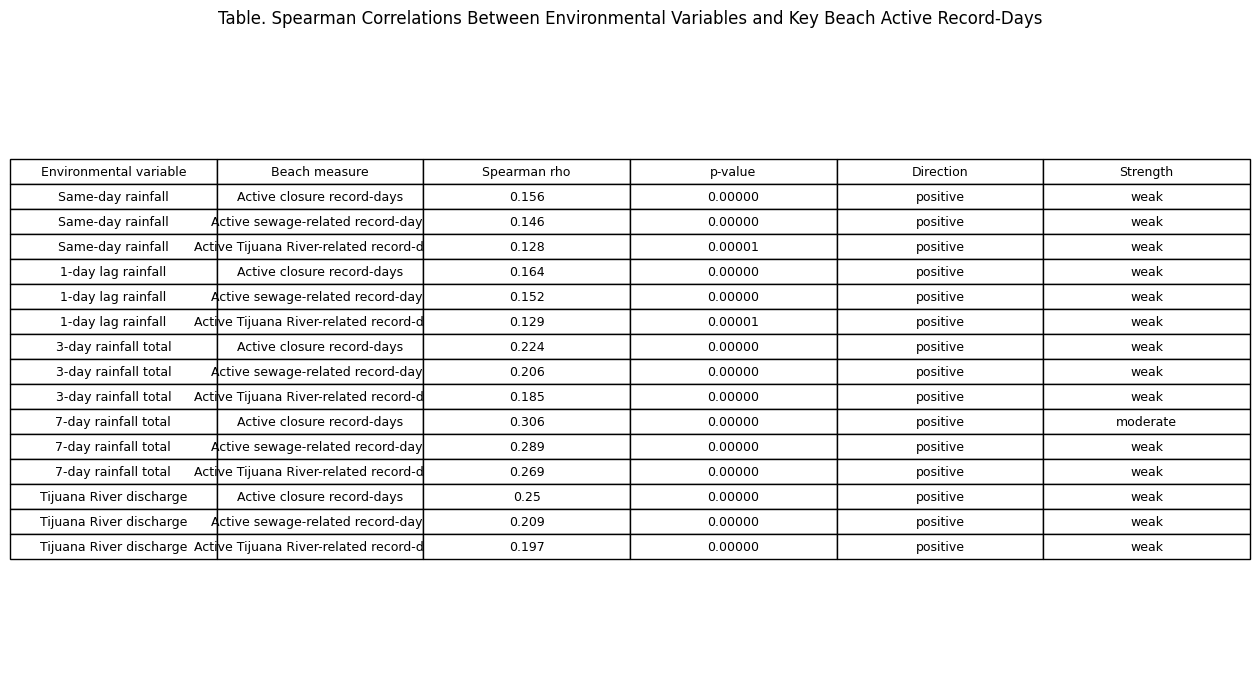

Saved report Spearman table
CSV path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/report_spearman_results_table.csv
CSV exists: True
Image path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/figures/report_spearman_results_table.png
Image exists: True


,Environmental variable,Beach measure,Spearman rho,p-value,Direction,Strength
1,Same-day rainfall,Active closure record-days,0.156,0.00000,positive,weak
3,Same-day rainfall,Active sewage-related record-days,0.146,0.00000,positive,weak
4,Same-day rainfall,Active Tijuana River-related record-days,0.128,0.00001,positive,weak
6,1-day lag rainfall,Active closure record-days,0.164,0.00000,positive,weak
8,1-day lag rainfall,Active sewage-related record-days,0.152,0.00000,positive,weak
9,1-day lag rainfall,Active Tijuana River-related record-days,0.129,0.00001,positive,weak
11,3-day rainfall total,Active closure record-days,0.224,0.00000,positive,weak
13,3-day rainfall total,Active sewage-related record-days,0.206,0.00000,positive,weak
14,3-day rainfall total,Active Tijuana River-related record-days,0.185,0.00000,positive,weak
16,7-day rainfall total,Active closure record-days,0.306,0.00000,positive,moderate


In [21]:
report_spearman_table = reloaded_spearman[
    reloaded_spearman["beach_column"].isin([
        "active_closure_records",
        "active_sewage_related_records",
        "active_tijuana_river_related_records"
    ])
].copy()

report_spearman_table = report_spearman_table[
    [
        "environmental_variable",
        "beach_measure",
        "spearman_rho",
        "p_value",
        "direction",
        "strength"
    ]
]

report_spearman_table = report_spearman_table.rename(columns={
    "environmental_variable": "Environmental variable",
    "beach_measure": "Beach measure",
    "spearman_rho": "Spearman rho",
    "p_value": "p-value",
    "direction": "Direction",
    "strength": "Strength"
})

report_spearman_table["Spearman rho"] = report_spearman_table["Spearman rho"].round(3)
report_spearman_table["p-value"] = report_spearman_table["p-value"].map(lambda x: f"{x:.5f}")

report_table_path = TABLES / "report_spearman_results_table.csv"
report_spearman_table.to_csv(report_table_path, index=False)

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")

table = ax.table(
    cellText=report_spearman_table.values,
    colLabels=report_spearman_table.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

ax.set_title("Table. Spearman Correlations Between Environmental Variables and Key Beach Active Record-Days", pad=20)

report_table_image_path = FIGURES / "report_spearman_results_table.png"
fig.savefig(report_table_image_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved report Spearman table")
print("=" * 70)
print(f"CSV path: {report_table_path}")
print(f"CSV exists: {report_table_path.exists()}")
print(f"Image path: {report_table_image_path}")
print(f"Image exists: {report_table_image_path.exists()}")

display(report_spearman_table)

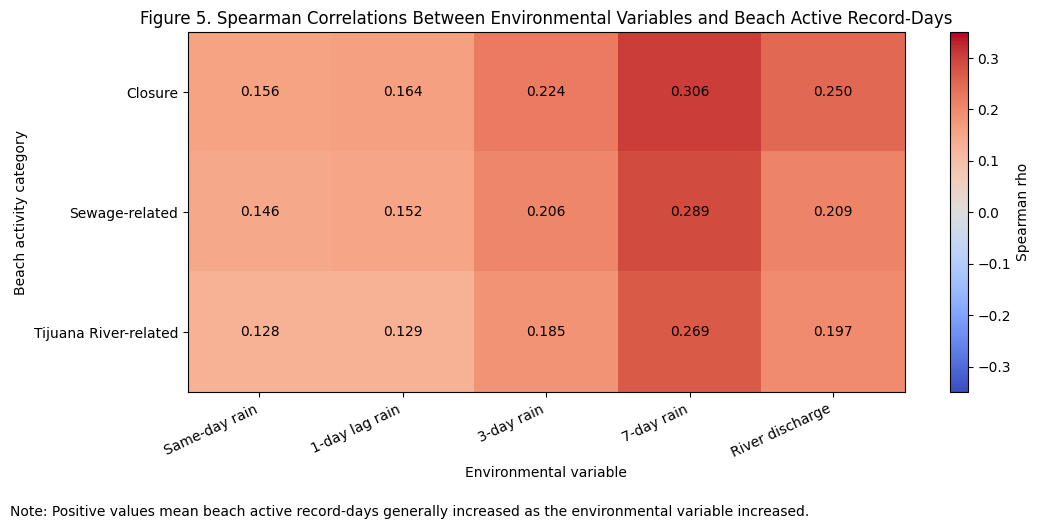

Saved Figure 5
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/figures/figure_5_spearman_correlation_heatmap.png
File exists: True


In [22]:
figure5_data = reloaded_spearman[
    reloaded_spearman["beach_column"].isin([
        "active_closure_records",
        "active_sewage_related_records",
        "active_tijuana_river_related_records"
    ])
].copy()

figure5_data["Environmental variable"] = figure5_data["environmental_variable"].replace({
    "Same-day rainfall": "Same-day rain",
    "1-day lag rainfall": "1-day lag rain",
    "3-day rainfall total": "3-day rain",
    "7-day rainfall total": "7-day rain",
    "Tijuana River discharge": "River discharge"
})

figure5_data["Beach measure"] = figure5_data["beach_measure"].replace({
    "Active closure record-days": "Closure",
    "Active sewage-related record-days": "Sewage-related",
    "Active Tijuana River-related record-days": "Tijuana River-related"
})

env_order = [
    "Same-day rain",
    "1-day lag rain",
    "3-day rain",
    "7-day rain",
    "River discharge"
]

beach_order = [
    "Closure",
    "Sewage-related",
    "Tijuana River-related"
]

heatmap_data = figure5_data.pivot(
    index="Beach measure",
    columns="Environmental variable",
    values="spearman_rho"
).loc[beach_order, env_order]

fig, ax = plt.subplots(figsize=(11, 5))

image = ax.imshow(heatmap_data, aspect="auto", vmin=-0.35, vmax=0.35, cmap="coolwarm")

ax.set_title("Figure 5. Spearman Correlations Between Environmental Variables and Beach Active Record-Days")
ax.set_xlabel("Environmental variable")
ax.set_ylabel("Beach activity category")

ax.set_xticks(np.arange(len(env_order)))
ax.set_yticks(np.arange(len(beach_order)))
ax.set_xticklabels(env_order, rotation=25, ha="right")
ax.set_yticklabels(beach_order)

for i in range(len(beach_order)):
    for j in range(len(env_order)):
        value = heatmap_data.iloc[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="black")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Spearman rho")

note_text = "Note: Positive values mean beach active record-days generally increased as the environmental variable increased."

fig.text(
    0.01,
    -0.02,
    note_text,
    ha="left",
    va="top",
    fontsize=10
)

plt.tight_layout()

figure5_path = FIGURES / "figure_5_spearman_correlation_heatmap.png"
fig.savefig(figure5_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 5")
print(f"Path: {figure5_path}")
print(f"File exists: {figure5_path.exists()}")

Figure 5 shows the Spearman correlations between rainfall, river discharge, and key beach active record-day categories. Spearman correlation helps show whether two variables generally move in the same direction. In this case, positive values mean that beach active record-days tended to increase when rainfall or river discharge increased.

The clearest pattern is that 7-day rainfall had the strongest relationship with beach impacts. It had the highest correlation with closure record-days, sewage-related record-days, and Tijuana River-related record-days. This suggests that recent rainfall over several days may be more connected to beach impacts than same-day rain alone. River discharge also had positive correlations with the same categories, but the relationships were weaker.

Overall, this heatmap supports the project's main idea that rainfall and Tijuana River flow are associated with higher beach-impact activity. However, the correlations are mostly weak to moderate, so these results should be interpreted as exploratory associations, not proof that rainfall or river flow directly caused the beach impacts.

In [23]:
# tests whether beach active record-days differ between rainy/dry
# days and high-flow/non-high-flow days.

from scipy.stats import mannwhitneyu

test_columns = [
    "active_advisory_records",
    "active_closure_records",
    "active_posting_records",
    "active_sewage_related_records",
    "active_tijuana_river_related_records"
]

test_labels = {
    "active_advisory_records": "Active advisory record-days",
    "active_closure_records": "Active closure record-days",
    "active_posting_records": "Active posting record-days",
    "active_sewage_related_records": "Active sewage-related record-days",
    "active_tijuana_river_related_records": "Active Tijuana River-related record-days"
}

comparison_groups = []

rainy_flag = daily["rainy_day"].astype(str).str.lower().isin(["true", "1", "yes"])

comparison_groups.append({
    "comparison_type": "Rainy vs dry",
    "comparison_column": "rainy_day",
    "group_1_label": "Rainy days",
    "group_2_label": "Dry days",
    "group_1_flag": rainy_flag
})

flow_windows = {
    "Same-day high-flow vs non-high-flow": "high_flow_day",
    "1-day high-flow window vs non-high-flow": "high_flow_1day_window",
    "3-day high-flow window vs non-high-flow": "high_flow_3day_window",
    "7-day high-flow window vs non-high-flow": "high_flow_7day_window"
}

for comparison_label, window_col in flow_windows.items():
    flow_flag = pd.to_numeric(daily[window_col], errors="coerce").fillna(0).astype(int) == 1

    comparison_groups.append({
        "comparison_type": comparison_label,
        "comparison_column": window_col,
        "group_1_label": "High-flow window days",
        "group_2_label": "Non-high-flow window days",
        "group_1_flag": flow_flag
    })

test_rows = []

for group in comparison_groups:
    group_1_flag = group["group_1_flag"]

    for col in test_columns:
        group_1_values = pd.to_numeric(daily.loc[group_1_flag, col], errors="coerce").dropna()
        group_2_values = pd.to_numeric(daily.loc[~group_1_flag, col], errors="coerce").dropna()

        u_statistic, p_value = mannwhitneyu(
            group_1_values,
            group_2_values,
            alternative="two-sided"
        )

        group_1_mean = group_1_values.mean()
        group_2_mean = group_2_values.mean()

        if group_2_mean == 0:
            percent_difference = np.nan
        else:
            percent_difference = ((group_1_mean - group_2_mean) / group_2_mean) * 100

        if p_value < 0.001:
            p_value_text = "p < 0.001"
        else:
            p_value_text = f"p = {p_value:.3f}"

        test_rows.append({
            "comparison_type": group["comparison_type"],
            "comparison_column": group["comparison_column"],
            "measure": test_labels[col],
            "column_name": col,
            "group_1": group["group_1_label"],
            "group_2": group["group_2_label"],
            "group_1_days": len(group_1_values),
            "group_2_days": len(group_2_values),
            "group_1_mean_active_record_days": group_1_mean,
            "group_2_mean_active_record_days": group_2_mean,
            "group_1_median_active_record_days": group_1_values.median(),
            "group_2_median_active_record_days": group_2_values.median(),
            "mean_difference_group_1_minus_group_2": group_1_mean - group_2_mean,
            "percent_difference_group_1_vs_group_2": percent_difference,
            "mann_whitney_u_statistic": u_statistic,
            "p_value": p_value,
            "p_value_text": p_value_text
        })

mann_whitney_results = pd.DataFrame(test_rows)

round_cols = [
    "group_1_mean_active_record_days",
    "group_2_mean_active_record_days",
    "group_1_median_active_record_days",
    "group_2_median_active_record_days",
    "mean_difference_group_1_minus_group_2",
    "percent_difference_group_1_vs_group_2",
    "mann_whitney_u_statistic",
    "p_value"
]

mann_whitney_results[round_cols] = mann_whitney_results[round_cols].round(5)

mann_whitney_path = TABLES / "daily_environmental_mann_whitney_tests.csv"
mann_whitney_results.to_csv(mann_whitney_path, index=False)

reloaded_mann_whitney = pd.read_csv(mann_whitney_path)

print("Saved Mann-Whitney U test results table")
print("=" * 70)
print(f"Path: {mann_whitney_path}")
print(f"File exists: {mann_whitney_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_mann_whitney)}")
print(f"Columns: {reloaded_mann_whitney.shape[1]}")
print(f"Missing values: {reloaded_mann_whitney.isna().sum().sum()}")

display(reloaded_mann_whitney)

Saved Mann-Whitney U test results table
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/daily_environmental_mann_whitney_tests.csv
File exists: True

Reloaded QA
Rows: 25
Columns: 17
Missing values: 0


,comparison_type,comparison_column,measure,column_name,group_1,group_2,group_1_days,group_2_days,group_1_mean_active_record_days,group_2_mean_active_record_days,group_1_median_active_record_days,group_2_median_active_record_days,mean_difference_group_1_minus_group_2,percent_difference_group_1_vs_group_2,mann_whitney_u_statistic,p_value,p_value_text
0,Rainy vs dry,rainy_day,Active advisory record-days,active_advisory_records,Rainy days,Dry days,80,1079,10.98750,11.15477,10.0,11.0,-0.16727,-1.49956,41492.5,0.56252,p = 0.563
1,Rainy vs dry,rainy_day,Active closure record-days,active_closure_records,Rainy days,Dry days,80,1079,6.37500,5.09268,6.0,5.0,1.28232,25.17971,54168.0,0.00011,p < 0.001
2,Rainy vs dry,rainy_day,Active posting record-days,active_posting_records,Rainy days,Dry days,80,1079,3.67500,5.94717,3.0,5.0,-2.27217,-38.20594,26687.0,0.00000,p < 0.001
3,Rainy vs dry,rainy_day,Active sewage-related record-days,active_sewage_related_records,Rainy days,Dry days,80,1079,6.35000,5.12141,6.0,5.0,1.22859,23.98932,53916.0,0.00016,p < 0.001
4,Rainy vs dry,rainy_day,Active Tijuana River-related record-days,active_tijuana_river_related_records,Rainy days,Dry days,80,1079,5.68750,4.92400,6.0,5.0,0.76350,15.50560,51373.5,0.00387,p = 0.004
5,Same-day high-flow vs non-high-flow,high_flow_day,Active advisory record-days,active_advisory_records,High-flow window days,Non-high-flow window days,291,868,11.92784,10.88018,12.0,11.0,1.04765,9.62898,144112.5,0.00030,p < 0.001
6,Same-day high-flow vs non-high-flow,high_flow_day,Active closure record-days,active_closure_records,High-flow window days,Non-high-flow window days,291,868,5.94158,4.92627,6.0,5.0,1.01531,20.61020,155665.0,0.00000,p < 0.001
7,Same-day high-flow vs non-high-flow,high_flow_day,Active posting record-days,active_posting_records,High-flow window days,Non-high-flow window days,291,868,5.45704,5.90207,5.0,5.0,-0.44503,-7.54022,115475.5,0.02789,p = 0.028
8,Same-day high-flow vs non-high-flow,high_flow_day,Active sewage-related record-days,active_sewage_related_records,High-flow window days,Non-high-flow window days,291,868,5.88660,4.97811,6.0,5.0,0.90849,18.24964,152365.0,0.00000,p < 0.001
9,Same-day high-flow vs non-high-flow,high_flow_day,Active Tijuana River-related record-days,active_tijuana_river_related_records,High-flow window days,Non-high-flow window days,291,868,5.31271,4.86406,6.0,5.0,0.44866,9.22398,146431.0,0.00003,p < 0.001


In [24]:
key_mann_whitney_summary = reloaded_mann_whitney[
    reloaded_mann_whitney["column_name"].isin([
        "active_closure_records",
        "active_sewage_related_records",
        "active_tijuana_river_related_records"
    ])
].copy()

key_mann_whitney_summary = key_mann_whitney_summary[
    [
        "comparison_type",
        "measure",
        "group_1",
        "group_2",
        "group_1_days",
        "group_2_days",
        "group_1_mean_active_record_days",
        "group_2_mean_active_record_days",
        "mean_difference_group_1_minus_group_2",
        "percent_difference_group_1_vs_group_2",
        "p_value_text"
    ]
].copy()

key_mann_whitney_summary = key_mann_whitney_summary.rename(columns={
    "comparison_type": "comparison",
    "measure": "beach_measure",
    "group_1_mean_active_record_days": "group_1_mean",
    "group_2_mean_active_record_days": "group_2_mean",
    "mean_difference_group_1_minus_group_2": "mean_difference",
    "percent_difference_group_1_vs_group_2": "percent_difference",
    "p_value_text": "mann_whitney_p_value"
})

round_cols = [
    "group_1_mean",
    "group_2_mean",
    "mean_difference",
    "percent_difference"
]

key_mann_whitney_summary[round_cols] = key_mann_whitney_summary[round_cols].round(2)

summary_path = TABLES / "mann_whitney_key_results_summary.csv"
key_mann_whitney_summary.to_csv(summary_path, index=False)

reloaded_key_mann_whitney = pd.read_csv(summary_path)

print("Saved key Mann-Whitney results summary table")
print("=" * 70)
print(f"Path: {summary_path}")
print(f"File exists: {summary_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_key_mann_whitney)}")
print(f"Columns: {reloaded_key_mann_whitney.shape[1]}")
print(f"Missing values: {reloaded_key_mann_whitney.isna().sum().sum()}")

display(reloaded_key_mann_whitney)

Saved key Mann-Whitney results summary table
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/mann_whitney_key_results_summary.csv
File exists: True

Reloaded QA
Rows: 15
Columns: 11
Missing values: 0


,comparison,beach_measure,group_1,group_2,group_1_days,group_2_days,group_1_mean,group_2_mean,mean_difference,percent_difference,mann_whitney_p_value
0,Rainy vs dry,Active closure record-days,Rainy days,Dry days,80,1079,6.38,5.09,1.28,25.18,p < 0.001
1,Rainy vs dry,Active sewage-related record-days,Rainy days,Dry days,80,1079,6.35,5.12,1.23,23.99,p < 0.001
2,Rainy vs dry,Active Tijuana River-related record-days,Rainy days,Dry days,80,1079,5.69,4.92,0.76,15.51,p = 0.004
3,Same-day high-flow vs non-high-flow,Active closure record-days,High-flow window days,Non-high-flow window days,291,868,5.94,4.93,1.02,20.61,p < 0.001
4,Same-day high-flow vs non-high-flow,Active sewage-related record-days,High-flow window days,Non-high-flow window days,291,868,5.89,4.98,0.91,18.25,p < 0.001
5,Same-day high-flow vs non-high-flow,Active Tijuana River-related record-days,High-flow window days,Non-high-flow window days,291,868,5.31,4.86,0.45,9.22,p < 0.001
6,1-day high-flow window vs non-high-flow,Active closure record-days,High-flow window days,Non-high-flow window days,327,832,5.92,4.89,1.03,21.06,p < 0.001
7,1-day high-flow window vs non-high-flow,Active sewage-related record-days,High-flow window days,Non-high-flow window days,327,832,5.87,4.95,0.92,18.56,p < 0.001
8,1-day high-flow window vs non-high-flow,Active Tijuana River-related record-days,High-flow window days,Non-high-flow window days,327,832,5.34,4.83,0.51,10.54,p < 0.001
9,3-day high-flow window vs non-high-flow,Active closure record-days,High-flow window days,Non-high-flow window days,383,776,5.88,4.84,1.04,21.58,p < 0.001


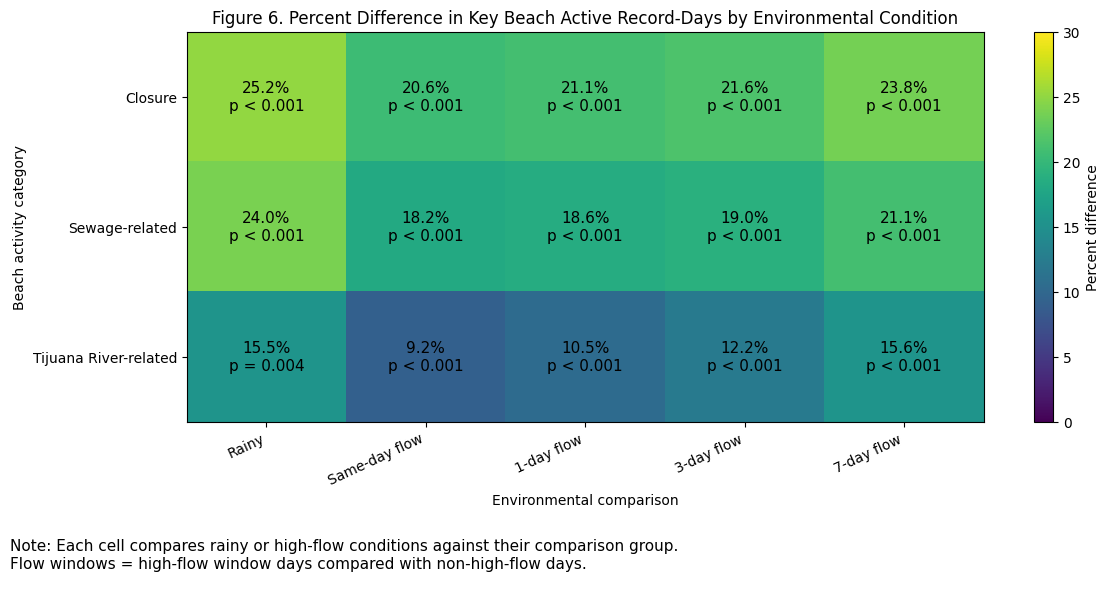

Saved Figure 6
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/figures/figure6_key_mann_whitney_heatmap.png
File exists: True


In [29]:
#figure 6

figure6_data = pd.read_csv(TABLES / "mann_whitney_key_results_summary.csv").copy()

figure6_data["short_comparison"] = figure6_data["comparison"].replace({
    "Rainy vs dry": "Rainy",
    "Same-day high-flow vs non-high-flow": "Same-day flow",
    "1-day high-flow window vs non-high-flow": "1-day flow",
    "3-day high-flow window vs non-high-flow": "3-day flow",
    "7-day high-flow window vs non-high-flow": "7-day flow"
})

figure6_data["short_beach_measure"] = figure6_data["beach_measure"].replace({
    "Active closure record-days": "Closure",
    "Active sewage-related record-days": "Sewage-related",
    "Active Tijuana River-related record-days": "Tijuana River-related"
})

comparison_order = ["Rainy", "Same-day flow", "1-day flow", "3-day flow", "7-day flow"]
beach_order = ["Closure", "Sewage-related", "Tijuana River-related"]

figure6_percent = (
    figure6_data
    .pivot(index="short_beach_measure", columns="short_comparison", values="percent_difference")
    .reindex(index=beach_order, columns=comparison_order)
)

figure6_pvals = (
    figure6_data
    .pivot(index="short_beach_measure", columns="short_comparison", values="mann_whitney_p_value")
    .reindex(index=beach_order, columns=comparison_order)
)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(figure6_percent.values, aspect="auto", vmin=0, vmax=30)

ax.set_title("Figure 6. Percent Difference in Key Beach Active Record-Days by Environmental Condition")
ax.set_xlabel("Environmental comparison")
ax.set_ylabel("Beach activity category")

ax.set_xticks(range(len(comparison_order)))
ax.set_xticklabels(comparison_order, rotation=25, ha="right")
ax.set_yticks(range(len(beach_order)))
ax.set_yticklabels(beach_order)

for i in range(figure6_percent.shape[0]):
    for j in range(figure6_percent.shape[1]):
        pct = figure6_percent.iloc[i, j]
        pval = figure6_pvals.iloc[i, j]
        ax.text(
            j, i,
            f"{pct:.1f}%\n{pval}",
            ha="center",
            va="center",
            fontsize=11
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Percent difference")

note_text = (
    "Note: Each cell compares rainy or high-flow conditions against their comparison group.\n"
    "Flow windows = high-flow window days compared with non-high-flow days.\n"
)

fig.text(0.01, 0.01, note_text, ha="left", va="bottom", fontsize=11)

plt.tight_layout(rect=[0, 0.12, 1, 1])

figure6_path = FIGURES / "figure6_key_mann_whitney_heatmap.png"
plt.savefig(figure6_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 6")
print("=" * 70)
print(f"Path: {figure6_path}")
print(f"File exists: {figure6_path.exists()}")

Figure 6 shows the percent difference in key beach active record-days during rainy days and river high-flow windows. The Mann-Whitney U test compares two groups using the order/rank of the values instead of assuming the data follows a bell-shaped distribution. Rainy days had higher closure active record-days by 25.2%, sewage-related active record-days by 24.0%, and Tijuana River-related active record-days by 15.5%. High-flow windows also showed higher values across all three categories, with the 7-day high-flow window showing the largest increase for closures at 23.8%.

The p-values show that these group differences were statistically significant. Most comparisons had p < 0.001, meaning the differences are unlikely to be due to random variation alone. However, because this is an exploratory project, these results should still be interpreted as evidence of association, not proof that rain or river flow directly caused the beach impacts.

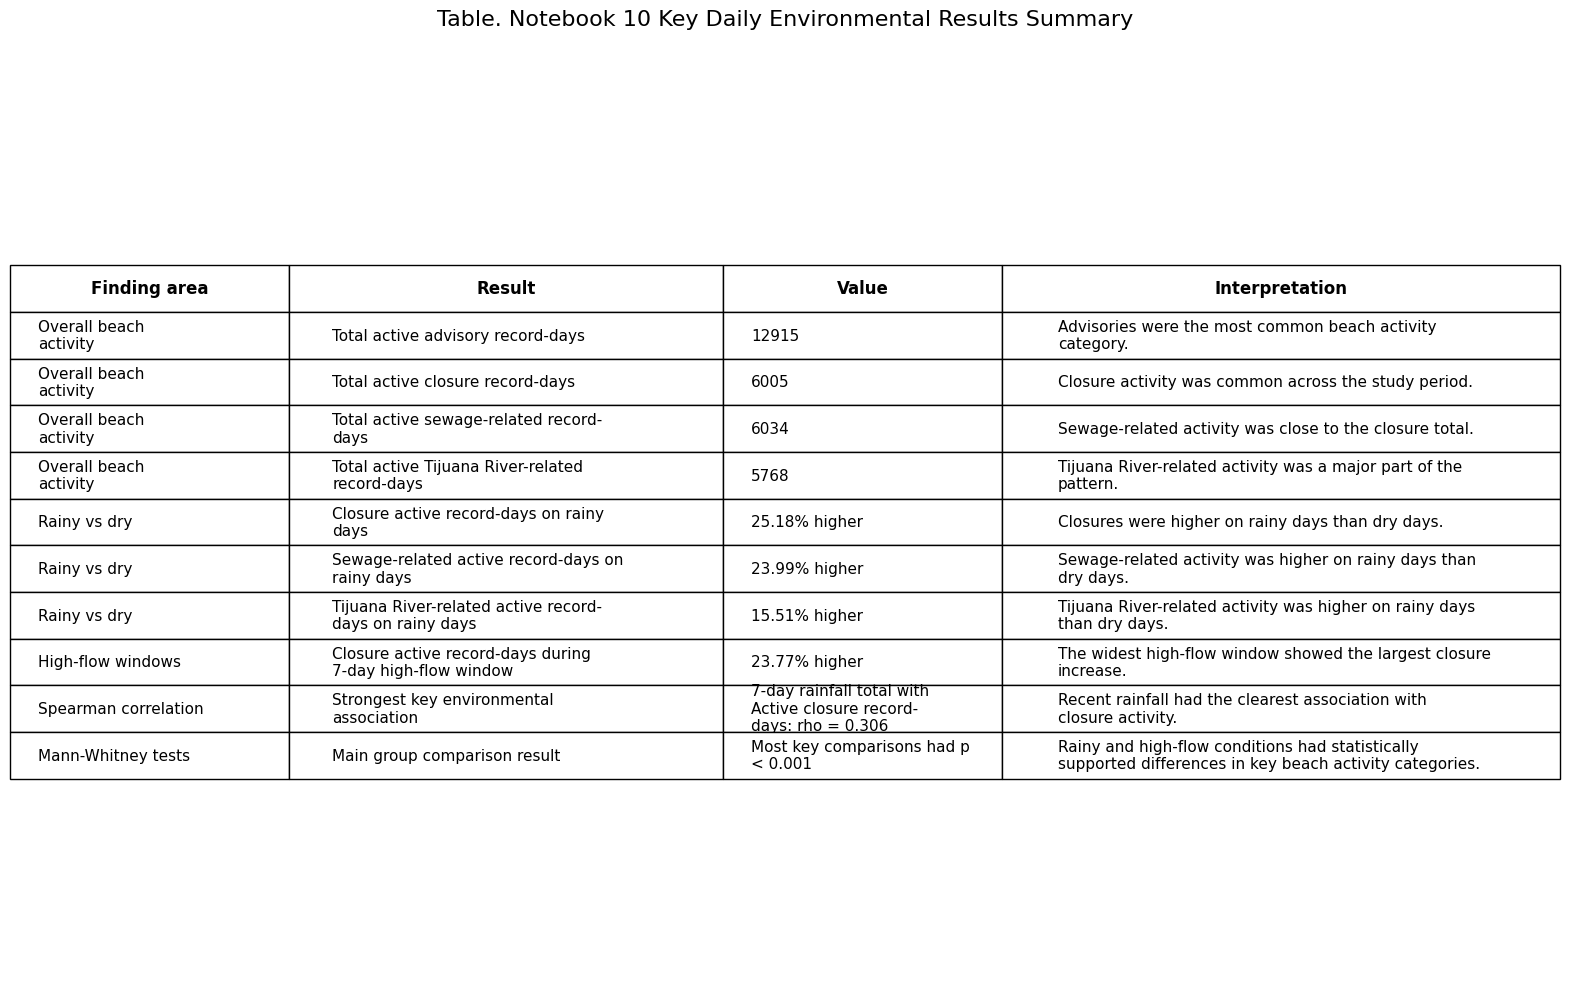

Saved larger key findings table image
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/figures/table_notebook10_key_daily_results_summary_large.png
File exists: True


In [32]:
from textwrap import fill

table_df = pd.read_csv(TABLES / "notebook10_key_daily_results_summary.csv").copy()

table_df["finding_area"] = table_df["finding_area"].apply(lambda x: fill(str(x), width=20))
table_df["result"] = table_df["result"].apply(lambda x: fill(str(x), width=38))
table_df["value"] = table_df["value"].apply(lambda x: fill(str(x), width=26))
table_df["interpretation"] = table_df["interpretation"].apply(lambda x: fill(str(x), width=55))

fig, ax = plt.subplots(figsize=(20, 12))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=["Finding area", "Result", "Value", "Interpretation"],
    cellLoc="left",
    loc="center",
    colWidths=[0.18, 0.28, 0.18, 0.36]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(1)
    cell.set_text_props(va="center")

    if row == 0:
        cell.set_text_props(weight="bold", ha="center", va="center")
        cell.set_fontsize(12)

ax.set_title(
    "Table. Notebook 10 Key Daily Environmental Results Summary",
    fontsize=16,
    pad=25
)

table_image_path = FIGURES / "table_notebook10_key_daily_results_summary_large.png"
fig.savefig(table_image_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved larger key findings table image")
print("=" * 70)
print(f"Path: {table_image_path}")
print(f"File exists: {table_image_path.exists()}")

In [34]:
notebook10_keywords = [
    "daily_environmental",
    "daily_active",
    "monthly_environmental",
    "rainy_vs_dry",
    "high_flow",
    "spearman",
    "mann_whitney",
    "notebook10",
    "figure",
    "table_notebook10"
]

table_files = []
for file_path in TABLES.glob("*.csv"):
    if any(keyword in file_path.name for keyword in notebook10_keywords):
        table_files.append(file_path)

figure_files = []
for file_path in FIGURES.glob("*.png"):
    if any(keyword in file_path.name for keyword in notebook10_keywords):
        figure_files.append(file_path)

inventory_rows = []

for file_path in sorted(table_files):
    inventory_rows.append({
        "notebook": "10_daily_environmental_results.ipynb",
        "output_type": "table_csv",
        "file_name": file_path.name,
        "folder": "tables",
        "file_path": str(file_path),
        "file_exists": file_path.exists()
    })

for file_path in sorted(figure_files):
    inventory_rows.append({
        "notebook": "10_daily_environmental_results.ipynb",
        "output_type": "figure_png",
        "file_name": file_path.name,
        "folder": "figures",
        "file_path": str(file_path),
        "file_exists": file_path.exists()
    })

notebook10_inventory = pd.DataFrame(inventory_rows)

inventory_path = TABLES / "notebook10_output_inventory.csv"
notebook10_inventory.to_csv(inventory_path, index=False)

reloaded_inventory = pd.read_csv(inventory_path)

print("Saved Notebook 10 output inventory")
print("=" * 70)
print(f"Path: {inventory_path}")
print(f"File exists: {inventory_path.exists()}")
print()
print("Reloaded QA")
print("=" * 70)
print(f"Rows: {len(reloaded_inventory)}")
print(f"Columns: {reloaded_inventory.shape[1]}")
print(f"Missing values: {reloaded_inventory.isna().sum().sum()}")
print(f"Outputs found: {reloaded_inventory['file_exists'].sum()} out of {len(reloaded_inventory)}")

display(reloaded_inventory)

Saved Notebook 10 output inventory
Path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/tables/notebook10_output_inventory.csv
File exists: True

Reloaded QA
Rows: 23
Columns: 6
Missing values: 0
Outputs found: 23 out of 23


,notebook,output_type,file_name,folder,file_path,file_exists
0,10_daily_environmental_results.ipynb,table_csv,daily_active_record_day_summary.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
1,10_daily_environmental_results.ipynb,table_csv,daily_environmental_dataset_summary.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
2,10_daily_environmental_results.ipynb,table_csv,daily_environmental_mann_whitney_tests.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
3,10_daily_environmental_results.ipynb,table_csv,daily_environmental_spearman_correlations.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
4,10_daily_environmental_results.ipynb,table_csv,high_flow_window_active_record_day_comparison.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
5,10_daily_environmental_results.ipynb,table_csv,mann_whitney_key_results_summary.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
6,10_daily_environmental_results.ipynb,table_csv,monthly_environmental_results_summary.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
7,10_daily_environmental_results.ipynb,table_csv,notebook10_key_daily_results_summary.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
8,10_daily_environmental_results.ipynb,table_csv,notebook10_output_inventory.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True
9,10_daily_environmental_results.ipynb,table_csv,rainy_vs_dry_active_record_day_comparison.csv,tables,/content/gdrive_results/MyDrive/STAT596/Projec...,True


In [35]:
import shutil
import pandas as pd
from IPython.display import display

REPORT_READY = DATA_RAW / "report_ready_results"
REPORT_READY_TABLES = REPORT_READY / "tables"
REPORT_READY_FIGURES = REPORT_READY / "figures"

REPORT_READY.mkdir(exist_ok=True)
REPORT_READY_TABLES.mkdir(exist_ok=True)
REPORT_READY_FIGURES.mkdir(exist_ok=True)

clean_tables = [
    "daily_environmental_dataset_summary.csv",
    "daily_active_record_day_summary.csv",
    "monthly_environmental_results_summary.csv",
    "rainy_vs_dry_active_record_day_comparison.csv",
    "high_flow_window_active_record_day_comparison.csv",
    "daily_environmental_spearman_correlations.csv",
    "daily_environmental_mann_whitney_tests.csv",
    "mann_whitney_key_results_summary.csv",
    "notebook10_key_daily_results_summary.csv"
]

clean_figures = [
    "figure_1_total_beach_active_record_days_by_category.png",
    "figure_2_monthly_beach_active_record_days_over_time.png",
    "figure3_rainy_vs_dry_mean_active_record_days.png",
    "figure_4_high_flow_window_percent_increase.png",
    "figure_5_spearman_correlation_heatmap.png",
    "figure6_key_mann_whitney_heatmap.png",
    "table_notebook10_key_daily_results_summary_large.png"
]

copy_rows = []

for file_name in clean_tables:
    source_path = TABLES / file_name
    destination_path = REPORT_READY_TABLES / file_name

    if source_path.exists():
        shutil.copy2(source_path, destination_path)

    copy_rows.append({
        "output_type": "table",
        "file_name": file_name,
        "source_exists": source_path.exists(),
        "copied_path": str(destination_path),
        "copied_exists": destination_path.exists()
    })

for file_name in clean_figures:
    source_path = FIGURES / file_name
    destination_path = REPORT_READY_FIGURES / file_name

    if source_path.exists():
        shutil.copy2(source_path, destination_path)

    copy_rows.append({
        "output_type": "figure",
        "file_name": file_name,
        "source_exists": source_path.exists(),
        "copied_path": str(destination_path),
        "copied_exists": destination_path.exists()
    })

clean_results_inventory = pd.DataFrame(copy_rows)

clean_inventory_path = REPORT_READY / "notebook10_clean_results_inventory.csv"
clean_results_inventory.to_csv(clean_inventory_path, index=False)

print("Saved cleanest Notebook 10 results")
print("=" * 70)
print(f"Report-ready folder: {REPORT_READY}")
print(f"Tables folder: {REPORT_READY_TABLES}")
print(f"Figures folder: {REPORT_READY_FIGURES}")
print(f"Inventory path: {clean_inventory_path}")
print()
print("QA")
print("=" * 70)
print(f"Total selected outputs: {len(clean_results_inventory)}")
print(f"Source files found: {clean_results_inventory['source_exists'].sum()} out of {len(clean_results_inventory)}")
print(f"Files copied: {clean_results_inventory['copied_exists'].sum()} out of {len(clean_results_inventory)}")

display(clean_results_inventory)

Saved cleanest Notebook 10 results
Report-ready folder: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/report_ready_results
Tables folder: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/report_ready_results/tables
Figures folder: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/report_ready_results/figures
Inventory path: /content/gdrive_results/MyDrive/STAT596/Project596_datafiles/report_ready_results/notebook10_clean_results_inventory.csv

QA
Total selected outputs: 16
Source files found: 16 out of 16
Files copied: 16 out of 16


,output_type,file_name,source_exists,copied_path,copied_exists
0,table,daily_environmental_dataset_summary.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
1,table,daily_active_record_day_summary.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
2,table,monthly_environmental_results_summary.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
3,table,rainy_vs_dry_active_record_day_comparison.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
4,table,high_flow_window_active_record_day_comparison.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
5,table,daily_environmental_spearman_correlations.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
6,table,daily_environmental_mann_whitney_tests.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
7,table,mann_whitney_key_results_summary.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
8,table,notebook10_key_daily_results_summary.csv,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
9,figure,figure_1_total_beach_active_record_days_by_cat...,True,/content/gdrive_results/MyDrive/STAT596/Projec...,True
